# MGWR mapping of convergence coefficients

In [ ]:
# Adding necessary libraries to Google Colab environment

# Installing the 'contextily' library for adding basemaps to plots.
# This library is useful for adding contextual geographical layers,
# such as maps, to visualizations. The '-q' flag is used to suppress
# unnecessary output during installation.
!pip install contextily -q

# Installing the 'splot' library for spatial data visualization.
# 'splot' works with PySAL to visualize spatial data, including spatial
# autocorrelation and cluster analysis.
!pip install splot -q

# Installing additional libraries for spatial analysis and visualization.
# 'mapclassify' provides classification schemes for choropleth mapping,
# which can be useful for grouping spatial data into classes. This helps
# to visualize variations across different spatial regions more effectively.
!pip install mapclassify -q

# Installing the 'mgwr' library for performing geographically weighted
# regression (GWR). GWR is useful for understanding spatially varying
# relationships between variables by estimating local regression models.
!pip install mgwr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.9/379.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.2 MB/s eta 0:00:00


In [ ]:
# Load libraries

# Library for plotting graphs and visualizations
import matplotlib.pyplot as plt

# Library for handling geospatial data
import geopandas as gpd

# Import GWR and MGWR for Geographically Weighted Regression
from mgwr.gwr import GWR, MGWR

# Import Sel_BW for selecting optimal bandwidth for GWR/MGWR
from mgwr.sel_bw import Sel_BW

# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

In [ ]:
##################################################################
# Application 6: Multiscale Geographically Weighted Regression(MGWR)
# URL: https://bit.ly/MGWRapp6
##################################################################

# 1. Load Data
# -------------------------------------
gdf = gpd.read_file(
    "https://github.com/quarcs-lab/data-quarcs/raw/refs/heads/master/"
    "indonesia514/gdfBeta.geojson"
)

# 2. Prepare Variables
# -------------------------------------
# - Dependent Variable: GDP growth ('g')
y = gdf["g"].values.reshape((-1, 1))  # Reshape to column vector

# - Independent Variable: Log GDP per capita (2010)
X = gdf[["ln_gdppc2010"]].values  # Ensure X is 2D

# - Spatial Coordinates: Extract X and Y coordinates
u, v = gdf["COORD_X"], gdf["COORD_Y"]
coords = list(zip(u, v))  # List of (x, y) tuples

# 3. Standardize Variables
# -------------------------------------
Zy = (y - y.mean(axis=0)) / y.std(axis=0)
ZX = (X - X.mean(axis=0)) / X.std(axis=0)

# 4. Select Optimal Bandwidth for MGWR
# -------------------------------------
mgwr_selector = Sel_BW(coords, Zy, ZX, multi=True)
mgwr_bw = mgwr_selector.search()

# 5. Fit the MGWR Model
# -------------------------------------
mgwr_results = MGWR(coords, Zy, ZX, mgwr_selector).fit()

# 6. Display Model Summary
# -------------------------------------
mgwr_results.summary()

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Model type                                                         Gaussian
Number of observations:                                                 514
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            404.242
Log-likelihood:                                                    -667.601
AIC:                                                               1339.202
AICc:                                                              1341.249
BIC:                                                              -2791.776
R2:                                                                   0.214
Adj. R2:                                                              0.212

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

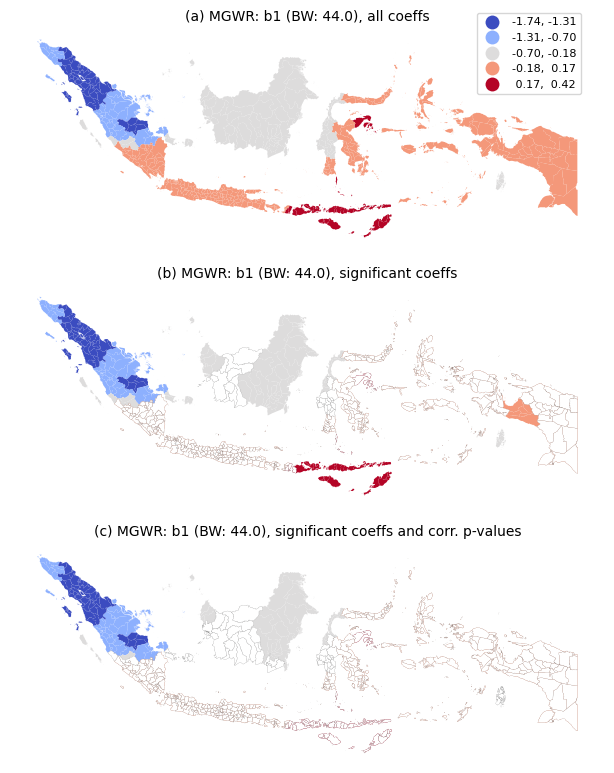

In [ ]:
##################################################################
# Application 7: MGWR mapping of convergence coefficients
# URL: https://bit.ly/MGWRapp7
##################################################################

# 1. Add MGWR Coefficients to the GeoDataFrame
# -------------------------------------
gdf["mgwr_intercept"] = mgwr_results.params[:, 0]
gdf["mgwr_b1"] = mgwr_results.params[:, 1]

# 2. Filter t-values for Significance
# -------------------------------------
# - Standard significance level (alpha = 0.05)
mgwr_filtered_t = mgwr_results.filter_tvals(alpha=0.05)

# - Adjusted significance level (corrected for multiple testing)
mgwr_filtered_tc = mgwr_results.filter_tvals()

# 3. Plot the b1 Coefficient
# -------------------------------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8))

# (a) Map of all b1 coefficients
gdf.plot(
    column="mgwr_b1",
    cmap="coolwarm",
    linewidth=0.01,
    scheme="FisherJenks",
    k=5,
    legend=True,
    legend_kwds={"bbox_to_anchor": (0.97, 1.10), "fontsize": 8},
    ax=axes[0]
)

# (b) Map highlighting statistically significant b1 coefficients (alpha = 0.05)
gdf.plot(
    column="mgwr_b1",
    cmap="coolwarm",
    linewidth=0.05,
    scheme="FisherJenks",
    k=5,
    legend=False,
    ax=axes[1]
)
gdf[mgwr_filtered_t[:, 1] == 0].plot(
    color="white",
    linewidth=0.05,
    edgecolor="black",
    ax=axes[1]
)

# (c) Map highlighting b1 coefficients with adjusted p-values
gdf.plot(
    column="mgwr_b1",
    cmap="coolwarm",
    linewidth=0.05,
    scheme="FisherJenks",
    k=5,
    legend=False,
    ax=axes[2]
)
gdf[mgwr_filtered_tc[:, 1] == 0].plot(
    color="white",
    linewidth=0.05,
    edgecolor="black",
    ax=axes[2]
)

# 4. Customize Layout and Appearance
# -------------------------------------
plt.tight_layout()

# Remove axes for a cleaner presentation
for ax in axes:
    ax.axis("off")

# Set subplot titles with consistent styling
axes[0].set_title(
    f"(a) MGWR: b1 (BW: {mgwr_bw[1]}), all coeffs", fontsize=10
)
axes[1].set_title(
    f"(b) MGWR: b1 (BW: {mgwr_bw[1]}), significant coeffs", fontsize=10
)
axes[2].set_title(
    f"(c) MGWR: b1 (BW: {mgwr_bw[1]}), significant coeffs and corr. p-values",
    fontsize=10
)

# 5. Save and Display the Figure
# -------------------------------------
plt.savefig("mgwr_b1.png", dpi=100, bbox_inches="tight")
plt.show()
